## Importation des modules

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, GRU,
    Dense, Dropout, BatchNormalization, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split


## Ingestion des données

In [2]:
df  = pd.read_csv(r'.\datafile\sequences.csv')


## Exploration des données

In [3]:
df.head(3)

,session_id,label,timestep,T,local_rate,local_density,burst_position,silence_before,pkt_len,ip_len,direction,up_ratio_local
0,ONU_capture_game_1,game,0,0.000000,1.0,0.0,0.0,0.000000,144,130,1,1.0
1,ONU_capture_game_1,game,1,3.033922,1.0,0.0,0.0,3.033922,131,117,0,0.0
2,ONU_capture_game_1,game,2,1.971815,1.0,0.0,0.0,1.971815,144,130,1,1.0


In [4]:
df.shape

(2408457, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408457 entries, 0 to 2408456
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   label           object 
 2   timestep        int64  
 3   T               float64
 4   local_rate      float64
 5   local_density   float64
 6   burst_position  float64
 7   silence_before  float64
 8   pkt_len         int64  
 9   ip_len          int64  
 10  direction       int64  
 11  up_ratio_local  float64
dtypes: float64(6), int64(4), object(2)
memory usage: 220.5+ MB


In [6]:
df.describe()

,timestep,T,local_rate,local_density,burst_position,silence_before,pkt_len,ip_len,direction,up_ratio_local
count,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06,2.408457e+06
mean,1.161470e+05,5.123555e-03,3.735412e+03,9.924744e-01,4.986487e-01,3.566087e-03,6.350812e+02,6.152673e+02,4.370296e-01,4.381209e-01
std,1.103356e+05,7.397551e-02,3.867572e+03,5.919694e-02,2.910824e-01,7.376842e-02,6.563391e+02,6.517493e+02,4.960190e-01,2.004661e-01
min,0.000000e+00,-4.053000e-06,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.554600e+04,2.312700e-05,5.320000e+02,1.000000e+00,2.469390e-01,0.000000e+00,6.000000e+01,4.000000e+01,0.000000e+00,3.118280e-01
50%,8.392500e+04,7.700900e-05,1.520000e+03,1.000000e+00,4.994310e-01,0.000000e+00,1.100000e+02,9.500000e+01,0.000000e+00,4.330940e-01
75%,1.742960e+05,1.349450e-04,8.720000e+03,1.000000e+00,7.502650e-01,0.000000e+00,1.444000e+03,1.430000e+03,1.000000e+00,5.592110e-01
max,4.636980e+05,1.019380e+01,1.149700e+04,1.000000e+00,1.000000e+00,1.019380e+01,5.477400e+04,1.500000e+03,1.000000e+00,1.000000e+00


## Choix des features

In [7]:
df_cor = df.drop("session_id", axis = 1)

In [8]:
df_cor.head(2)

,label,timestep,T,local_rate,local_density,burst_position,silence_before,pkt_len,ip_len,direction,up_ratio_local
0,game,0,0.000000,1.0,0.0,0.0,0.000000,144,130,1,1.0
1,game,1,3.033922,1.0,0.0,0.0,3.033922,131,117,0,0.0


#### Encodage du label et corrélations

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
encoder = LabelEncoder()
df_cor['label'] = encoder.fit_transform(df_cor['label']) + 1 

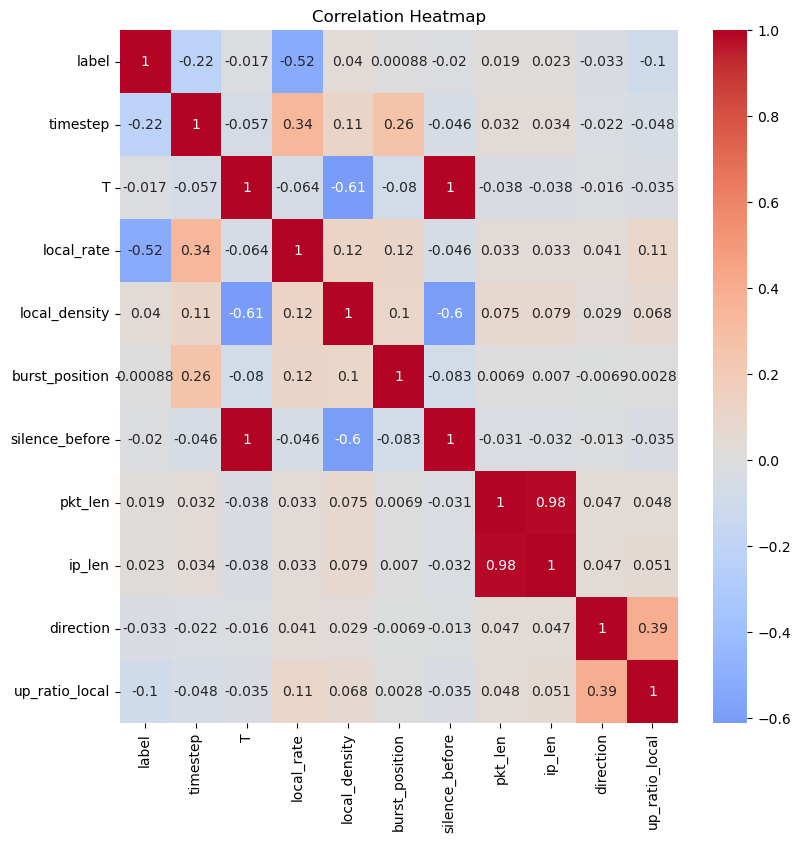

In [11]:
plt.figure(figsize=(9, 9))
sns.heatmap(df_cor.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

#### Choix des features les plus pertinents

In [3]:
SEQ_LEN = 50  # use last 50 packets to predict the next one

INPUT_FEATURES = ['local_rate','ip_len',
                  'local_density', 'burst_position', 'silence_before']
TARGET_FEATURES = ['T', 'pkt_len']  # what we predict

In [4]:
X_all, y_all, meta = [], [], []

for session_id, group in df.groupby('session_id'):
    group = group.sort_values('timestep')
    label = group['label'].iloc[0]
    data  = group[INPUT_FEATURES].values.astype(float)

    # --- normalize per session per feature ---
    mins = data.min(axis=0)
    maxs = data.max(axis=0)
    data_norm = (data - mins) / (maxs - mins + 1e-9)

    # --- sliding window: X = window of SEQ_LEN, y = next timestep ---
    for i in range(SEQ_LEN, len(data_norm)):
        X_all.append(data_norm[i - SEQ_LEN:i])             # (SEQ_LEN, 6)
        y_all.append(data_norm[i, :2])                      # (2,) → [T, packet_length]
        meta.append({'session_id': session_id, 'label': label, 'timestep': i})

X = np.stack(X_all).astype(np.float16)  # (total_windows, SEQ_LEN, 6)
y = np.stack(y_all).astype(np.float16)  # (total_windows, 2)

print("X shape:", X.shape) 
print("y shape:", y.shape) 


X shape: (2406407, 50, 5)
y shape: (2406407, 2)


## Séparation des données

In [5]:
X_train, X_test,  y_train, y_test  = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val,   y_train, y_val   = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Train: (1738628, 50, 5) | Val: (306817, 50, 5) | Test: (360962, 50, 5)


## Développement du modèle

#### Architecture

In [15]:
inputs = Input(shape=(SEQ_LEN, len(INPUT_FEATURES)))   # (50, 5)

x = GRU(128, return_sequences=True)(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = GRU(32)(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(16, activation='relu')(x)

# Two separate output heads — one per target
out_T      = Dense(1, activation='linear', name='T')(x)           # predict interval
out_length = Dense(1, activation='linear', name='pkt_len')(x)  # predict length


In [19]:
model = Model(inputs=inputs, outputs=[out_T, out_length])

model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss={'T': 'mse', 'pkt_len': 'mse'},
    metrics={'T': 'mae', 'pkt_len': 'mae'}
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 50, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru (GRU)                     │ (None, 50, 128)           │          51,840 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 50, 128)           │             512 │ gru[0][0]                  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 50, 128)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_1 (GRU)                   │ (None, 32)                │          15,552 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 32)                │             128 │ gru_1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32)                │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │             528 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ T (Dense)                     │ (None, 1)                 │              17 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pkt_len (Dense)               │ (None, 1)                 │              17 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 68,594 (267.95 KB)

 Trainable params: 68,274 (266.70 KB)

 Non-trainable params: 320 (1.25 KB)

In [17]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]


#### Entrainement

In [20]:
history = model.fit(
    X_train,
    {'T': y_train[:, 0], 'pkt_len': y_train[:, 1]},
    validation_data=(
        X_val,
        {'T': y_val[:, 0], 'pkt_len': y_val[:, 1]}
    ),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 6161s 226ms/step - T_loss: 0.0072 - T_mae: 0.0632 - loss: 0.1050 - pkt_len_loss: 0.0978 - pkt_len_mae: 0.2383 - val_T_loss: 0.0062 - val_T_mae: 0.0638 - val_loss: 0.0999 - val_pkt_len_loss: 0.0936 - val_pkt_len_mae: 0.2366 - learning_rate: 0.0100
Epoch 2/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 5349s 197ms/step - T_loss: 0.0074 - T_mae: 0.0636 - loss: 0.1115 - pkt_len_loss: 0.1041 - pkt_len_mae: 0.2531 - val_T_loss: 0.0047 - val_T_mae: 0.0557 - val_loss: 0.0903 - val_pkt_len_loss: 0.0856 - val_pkt_len_mae: 0.2163 - learning_rate: 0.0100
Epoch 3/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 5401s 198ms/step - T_loss: 0.0070 - T_mae: 0.0623 - loss: 0.1103 - pkt_len_loss: 0.1033 - pkt_len_mae: 0.2508 - val_T_loss: 0.0046 - val_T_mae: 0.0512 - val_loss: 0.0961 - val_pkt_len_loss: 0.0914 - val_pkt_len_mae: 0.2142 - learning_rate: 0.0100
Epoch 4/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - T_loss: 0.0071 - T_mae: 0.0630 - loss: 0.1076 - pkt_len_loss: 0.100

#### Evaluation du modèle

In [22]:
results = model.evaluate(
    X_test,
    {'T': y_test[:, 0], 'pkt_len': y_test[:, 1]},
    verbose=0
)
print(f"\nTest loss      : {results[0]:.6f}")
print(f"Test MAE (T)   : {results[1]:.6f}")
print(f"Test MAE (len) : {results[2]:.6f}")


Test loss      : 0.100108
Test MAE (T)   : 0.006283
Test MAE (len) : 0.093823


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step


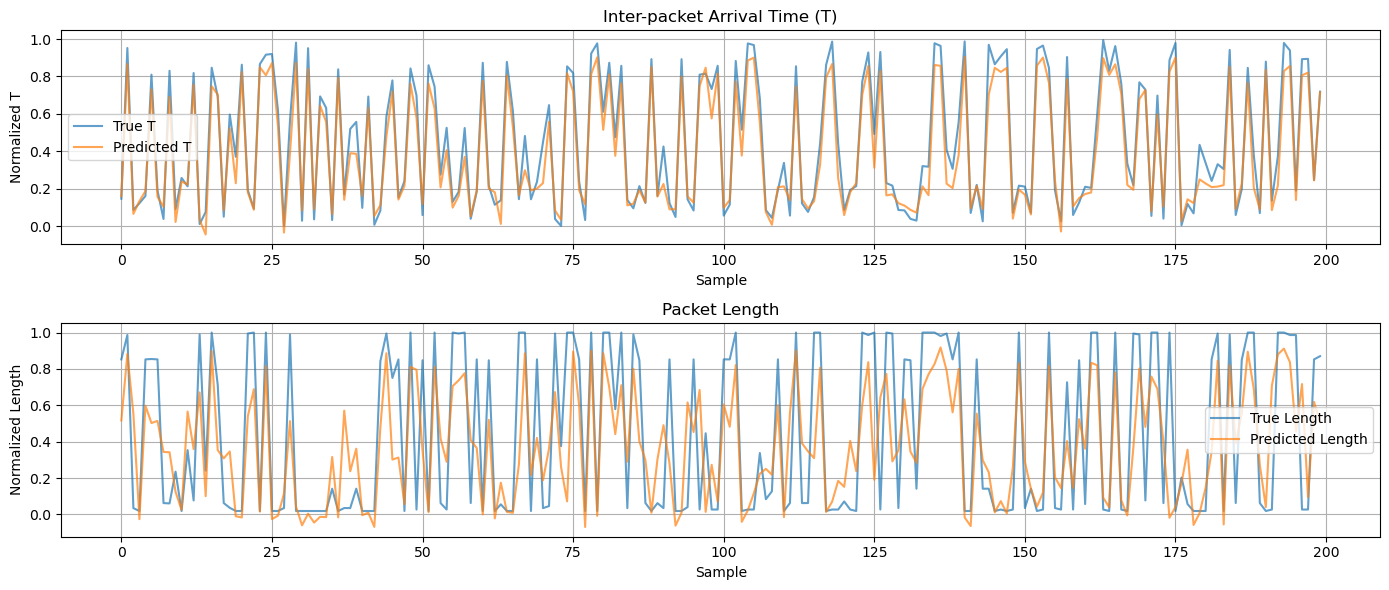

In [23]:
# ── 7. Predict & visualize ─────────────────────────────────────────────────
pred_T, pred_len = model.predict(X_test[:200])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(y_test[:200, 0], label='True T',            alpha=0.7)
axes[0].plot(pred_T[:, 0],    label='Predicted T',       alpha=0.7)
axes[0].set_title('Inter-packet Arrival Time (T)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Normalized T')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(y_test[:200, 1],   label='True Length',          alpha=0.7)
axes[1].plot(pred_len[:, 0],    label='Predicted Length',      alpha=0.7)
axes[1].set_title('Packet Length')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Normalized Length')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(r'.\datafile\gru_predictions.png', dpi=150)
plt.show()


In [24]:
# ── 8. Save model ──────────────────────────────────────────────────────────
model.save(r'.\datafile\gru_model.keras')
print("Model saved.")

Model saved.


## Comparaison avec un modèle GRU simple

In [6]:
# ── Input ──────────────────────────────────────────────────────────────────
inputs = Input(shape=(SEQ_LEN, len(INPUT_FEATURES)))        # (batch, 50, 6)

# ── Bloc 1 : Conv1D — extraction de patterns locaux ───────────────────────
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)                            # (batch, 50, 128) → (batch, 25, 128)
x = Dropout(0.2)(x)

# ── Bloc 2 : GRU unique — dépendances temporelles ─────────────────────────
x = GRU(64)(x)                                              # (batch, 25, 128) → (batch, 64)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# ── Bloc 3 : Dense — représentation finale ────────────────────────────────
x = Dense(32, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)

# ── Deux têtes de sortie ───────────────────────────────────────────────────
out_T      = Dense(1, activation='linear', name='T')(x)
out_length = Dense(1, activation='linear', name='pkt_len')(x)

In [7]:
model = Model(inputs=inputs, outputs=[out_T, out_length])

model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss={'T': 'mse', 'pkt_len': 'mse'},
    metrics={'T': 'mae', 'pkt_len': 'mae'}
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 50, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 50, 128)           │           3,328 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 50, 128)           │             512 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 25, 128)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 25, 128)           │               0 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru (GRU)                     │ (None, 64)                │          37,248 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 64)                │             256 │ gru[0][0]                  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │           2,080 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             528 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ T (Dense)                     │ (None, 1)                 │              17 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pkt_len (Dense)               │ (None, 1)                 │              17 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 43,986 (171.82 KB)

 Trainable params: 43,602 (170.32 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]


In [9]:
history = model.fit(
    X_train,
    {'T': y_train[:, 0], 'pkt_len': y_train[:, 1]},
    validation_data=(
        X_val,
        {'T': y_val[:, 0], 'pkt_len': y_val[:, 1]}
    ),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2210s 81ms/step - T_loss: 0.0081 - T_mae: 0.0676 - loss: 0.0932 - pkt_len_loss: 0.0851 - pkt_len_mae: 0.2101 - val_T_loss: 0.0082 - val_T_mae: 0.0721 - val_loss: 0.0854 - val_pkt_len_loss: 0.0772 - val_pkt_len_mae: 0.1865 - learning_rate: 0.0100
Epoch 2/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2142s 79ms/step - T_loss: 0.0069 - T_mae: 0.0633 - loss: 0.0906 - pkt_len_loss: 0.0837 - pkt_len_mae: 0.2061 - val_T_loss: 0.0052 - val_T_mae: 0.0550 - val_loss: 0.0928 - val_pkt_len_loss: 0.0876 - val_pkt_len_mae: 0.2329 - learning_rate: 0.0100
Epoch 3/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2181s 80ms/step - T_loss: 0.0063 - T_mae: 0.0604 - loss: 0.0886 - pkt_len_loss: 0.0823 - pkt_len_mae: 0.2032 - val_T_loss: 0.0046 - val_T_mae: 0.0547 - val_loss: 0.0819 - val_pkt_len_loss: 0.0773 - val_pkt_len_mae: 0.1869 - learning_rate: 0.0100
Epoch 4/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2061s 76ms/step - T_loss: 0.0063 - T_mae: 0.0598 - loss: 0.0891 - pkt_len_loss: 0.0828

### Evaluation du modèle

In [10]:
results = model.evaluate(
    X_test,
    {'T': y_test[:, 0], 'pkt_len': y_test[:, 1]},
    verbose=0
)
print(f"\nTest loss      : {results[0]:.6f}")
print(f"Test MAE (T)   : {results[1]:.6f}")
print(f"Test MAE (len) : {results[2]:.6f}")


Test loss      : 0.077774
Test MAE (T)   : 0.003645
Test MAE (len) : 0.074128


### Test sur prédiction et visualisation

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step


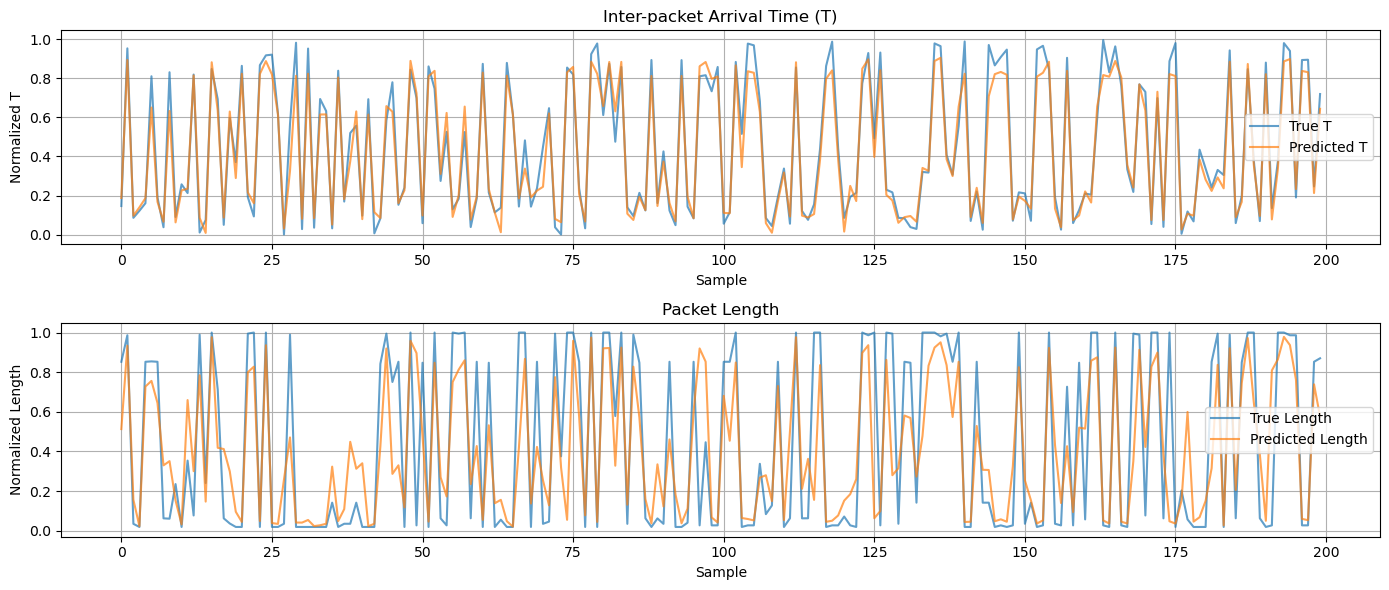

In [11]:
# ── 7. Predict & visualize ─────────────────────────────────────────────────
pred_T, pred_len = model.predict(X_test[:200])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(y_test[:200, 0], label='True T',            alpha=0.7)
axes[0].plot(pred_T[:, 0],    label='Predicted T',       alpha=0.7)
axes[0].set_title('Inter-packet Arrival Time (T)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Normalized T')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(y_test[:200, 1],   label='True Length',          alpha=0.7)
axes[1].plot(pred_len[:, 0],    label='Predicted Length',      alpha=0.7)
axes[1].set_title('Packet Length')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Normalized Length')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(r'.\datafile\gru_predictions.png', dpi=150)
plt.show()


### Ajout d'un CNN pour l'extraction des patterns locaux

In [14]:
# ── Input ──────────────────────────────────────────────────────────────────
inputs = Input(shape=(SEQ_LEN, len(INPUT_FEATURES)))        # (batch, 50, 6)

# ── Bloc 1 : Conv1D — extraction de patterns locaux ───────────────────────
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)                            # (batch, 50, 128) → (batch, 25, 128)
x = Dropout(0.2)(x)

# ── Bloc 2 : GRU unique — dépendances temporelles ─────────────────────────
# retrun_sequences retourne la séquence au deuxième GRU
x = GRU(64, return_sequences=True)(x)                                              # (batch, 25, 64)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# ──  Bloc 3 : Retourne un condensé de la séquence
x = GRU(32)(x)                                              # (batch, 32)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# ── Bloc 3 : Dense — représentation finale ────────────────────────────────
x = Dense(32, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)

# ── Deux têtes de sortie ───────────────────────────────────────────────────
out_T      = Dense(1, activation='linear', name='T')(x)
out_length = Dense(1, activation='linear', name='pkt_len')(x)

In [15]:
model_2 = Model(inputs=inputs, outputs=[out_T, out_length])

model_2.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss={'T': 'mse', 'pkt_len': 'mse'},
    metrics={'T': 'mae', 'pkt_len': 'mae'}
)

model_2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 50, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 50, 128)           │           3,328 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 50, 128)           │             512 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_2               │ (None, 25, 128)           │               0 │ batch_normalization_3[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 25, 128)           │               0 │ max_pooling1d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_2 (GRU)                   │ (None, 25, 64)            │          37,248 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 25, 64)            │             256 │ gru_2[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_5 (Dropout)           │ (None, 25, 64)            │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_3 (GRU)                   │ (None, 32)                │           9,408 │ dropout_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 32)                │             128 │ gru_3[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 32)                │               0 │ batch_normalization_5[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           1,056 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 32)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16)                │             528 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ T (Dense)                     │ (None, 1)                 │              17 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 52,498 (205.07 KB)

 Trainable params: 52,050 (203.32 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
history = model_2.fit(
    X_train,
    {'T': y_train[:, 0], 'pkt_len': y_train[:, 1]},
    validation_data=(
        X_val,
        {'T': y_val[:, 0], 'pkt_len': y_val[:, 1]}
    ),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2828s 103ms/step - T_loss: 0.0097 - T_mae: 0.0744 - loss: 0.1080 - pkt_len_loss: 0.0984 - pkt_len_mae: 0.2323 - val_T_loss: 0.0059 - val_T_mae: 0.0618 - val_loss: 0.0991 - val_pkt_len_loss: 0.0931 - val_pkt_len_mae: 0.2229 - learning_rate: 0.0100
Epoch 2/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2764s 101ms/step - T_loss: 0.0111 - T_mae: 0.0800 - loss: 0.1171 - pkt_len_loss: 0.1059 - pkt_len_mae: 0.2471 - val_T_loss: 0.0259 - val_T_mae: 0.1317 - val_loss: 0.1212 - val_pkt_len_loss: 0.0953 - val_pkt_len_mae: 0.2360 - learning_rate: 0.0100
Epoch 3/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 2427s 89ms/step - T_loss: 0.0126 - T_mae: 0.0850 - loss: 0.1218 - pkt_len_loss: 0.1092 - pkt_len_mae: 0.2535 - val_T_loss: 0.0136 - val_T_mae: 0.0960 - val_loss: 0.1178 - val_pkt_len_loss: 0.1041 - val_pkt_len_mae: 0.2527 - learning_rate: 0.0100
Epoch 4/10
27167/27167 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - T_loss: 0.0139 - T_mae: 0.0889 - loss: 0.1344 - pkt_len_loss: 0.1205

In [17]:
results = model_2.evaluate(
    X_test,
    {'T': y_test[:, 0], 'pkt_len': y_test[:, 1]},
    verbose=0
)
print(f"\nTest loss      : {results[0]:.6f}")
print(f"Test MAE (T)   : {results[1]:.6f}")
print(f"Test MAE (len) : {results[2]:.6f}")


Test loss      : 0.099418
Test MAE (T)   : 0.005937
Test MAE (len) : 0.093477


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


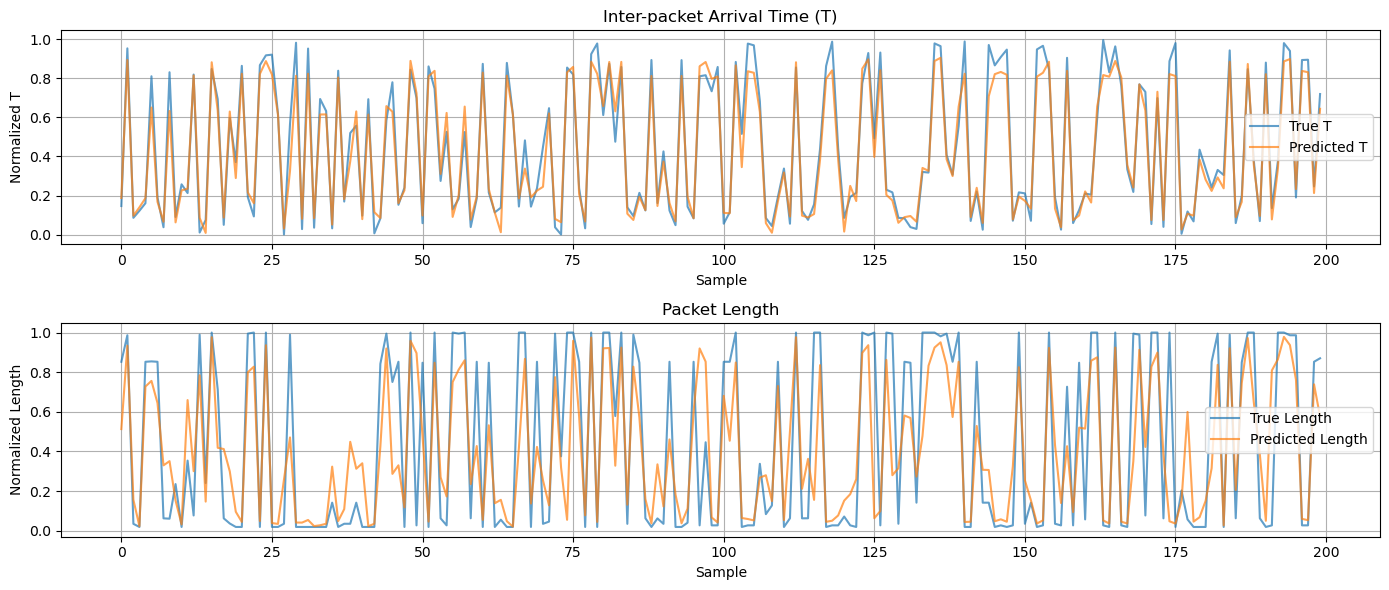

In [18]:
# ── 7. Predict & visualize ─────────────────────────────────────────────────
pred_T, pred_len = model.predict(X_test[:200])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(y_test[:200, 0], label='True T',            alpha=0.7)
axes[0].plot(pred_T[:, 0],    label='Predicted T',       alpha=0.7)
axes[0].set_title('Inter-packet Arrival Time (T)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Normalized T')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(y_test[:200, 1],   label='True Length',          alpha=0.7)
axes[1].plot(pred_len[:, 0],    label='Predicted Length',      alpha=0.7)
axes[1].set_title('Packet Length')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Normalized Length')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(r'.\datafile\2-gru_predictions.png', dpi=150)
plt.show()
